### What is a Perceptron?

A perceptron is atype of neuron that takes in several inputs and produces binary output/decision.

we'll train it on two classic logical problems: **AND** and **OR**. These datasets are **linearly separable**, meaning a straight line can separate the two classes. The perceptron will learn the correct weights to achieve perfect classification

## Real‑World Analogy: Loan Approval

imagine you are a bank officer deciding whether to approve a loan or not.You look at 2 factors:
- **Income** (x₁) - high income is good.
- **credit score** (x₂) - high score is good.

You might approve the loan if `0.6·x₁ + 0.3·x₂ > 0.5`. This is exactly what a perceptron does: it multiplies inputs by weights, adds them, and checks if the sum exceeds a threshold. The weights (`0.6`, `0.3`) and threshold (the bias) are learned from examples.

Of course, real loan approval is more complex, but this captures the idea of linear decision boundaries.

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src')))
from perceptron import Perceptron
print("✅ Import successful!")

✅ Import successful!


We import NumPy for math, Matplotlib for plotting, and our custom Perceptron class from the src folder.
The sys.path.append allows Python to find the module.

#### Define a Helper Function for Plotting (Code)

In [21]:
def plot_decision_boundary(X, y, model, title):
    """Plot the data points and the decision boundary learned by the perceptron."""
    # Create a mesh grid covering the input space
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.1, 0.5, 1.1], colors=['blue', 'red'])
    plt.scatter(X[y==0,0], X[y==0,1], color='blue', label='Class 0', edgecolor='k')
    plt.scatter(X[y==1,0], X[y==1,1], color='red', label='Class 1', edgecolor='k')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(title)
    plt.legend()
    plt.show()

This function creates a dense grid of points, runs the perceptron on each, and plots the resulting decision regions. The boundary is where the output changes from 0 to 1.

## 1. AND Dataset

The AND function outputs 1 only when both inputs are 1.

#### Create AND Data 

In [26]:
# AND dataset
X_and = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float64)
y_and = np.array([0, 0, 0, 1], dtype=np.float64)

print("AND truth table:")
for i in range(len(X_and)):
    print(f"{X_and[i]} -> {y_and[i]}")

AND truth table:
[0. 0.] -> 0.0
[0. 1.] -> 0.0
[1. 0.] -> 0.0
[1. 1.] -> 1.0


We create the four possible inputs and the corresponding outputs. `dtype=np.float64` ensures numeric operations work smoothly.

#### Train Perceptron on AND 

In [27]:
# Create perceptron with learning rate 0.1 and 10 epochs (passes over data)
p_and = Perceptron(learning_rate=0.1, n_iterations=10)
p_and.fit(X_and, y_and)

# Predictions
preds_and = p_and.predict(X_and)
print("Predictions:", preds_and)
print("Actual:     ", y_and)

Predictions: [0 0 0 1]
Actual:      [0. 0. 0. 1.]


We instantiate the perceptron, train it, and print the predictions. For AND, after a few epochs it should output `[0 0 0 1]`.

#### Visualize AND Decision Boundary

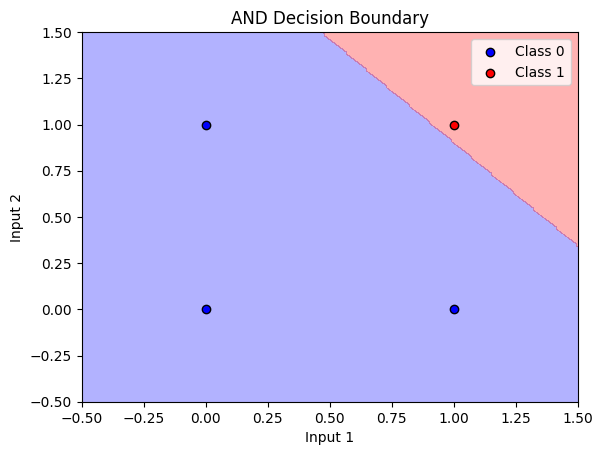

In [29]:
plot_decision_boundary(X_and, y_and, p_and, 'AND Decision Boundary')

The decision boundary should separate the (1,1) point from the others. Because the data is linearly separable, the line will be straight.

### Discussion of AND Results

The perceptron successfully learned AND. The decision boundary is a straight line that separates the red point (class 1) from the blue points (class 0). This works because AND is linearly separable.

## 2. OR Dataset

The OR function outputs 1 if at least one input is 1.

#### Create OR Data 

In [32]:
# OR dataset
X_or = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float64)
y_or = np.array([0, 1, 1, 1], dtype=np.float64)

print("OR truth table:")
for i in range(len(X_or)):
    print(f"{X_or[i]} -> {y_or[i]}")

OR truth table:
[0. 0.] -> 0.0
[0. 1.] -> 1.0
[1. 0.] -> 1.0
[1. 1.] -> 1.0


#### train Perceptron on OR

In [34]:
p_or = Perceptron(learning_rate=0.1, n_iterations=10)
p_or.fit(X_or, y_or)

preds_or = p_or.predict(X_or)
print("Predictions:", preds_or)
print("Actual:     ", y_or)

Predictions: [0 1 1 1]
Actual:      [0. 1. 1. 1.]


#### Visualize OR Decision Boundary 

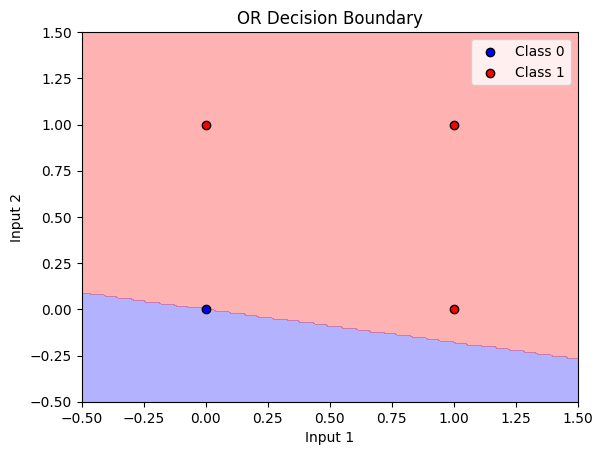

In [35]:
plot_decision_boundary(X_or, y_or, p_or, 'OR Decision Boundary')

#### Discussion of OR Results

Again, the perceptron learns perfectly. The decision boundary separates the single blue point (0,0) from the three red points.

## Summary

We've built a perceptron from scratch and successfully trained it on the linearly separable AND and OR datasets. the key takeaways:
- A perceptron learns weights and a bias to separate classes with a straight line
- It converges when the data is linearly separable
- In the next part, we'll tackle XOR, which is **not** linearly separable – a single neuron fails, and we'll need a multi‑layer network

**Key insight:** The perceptron's decision boundary is always a hyperplane (a line in 2D)(a line cutting 2d plan,dont mind about this much, just search hyperplanes on YT and you'll get a visual intuition of what it is). For more complex patterns, we need hidden layers and non‑linear activation functions.